# RNN learning map

**Learning objective:** Understand where recurrent models fit, the learning sequence, and the tensor conventions used throughout the track.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


## Why recurrent networks exist
        Feed-forward networks treat examples as independent. Sequence problems are different: order carries information. RNNs introduce a **state** that is updated one timestep at a time, creating a learnable summary of the past.

        We will move from `SimpleRNN` to LSTM and GRU, then connect them to forecasting, evaluation, inference and monitoring.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:03.358268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974783.373993    2703 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974783.378358    2703 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:05.057077: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
tasks = pd.DataFrame({
    "problem": ["sensor forecasting", "sentiment", "sequence labeling", "sequence generation"],
    "input": ["many timesteps", "many tokens", "many tokens", "prefix"],
    "output": ["future value", "one label", "label per token", "next token(s)"],
    "shape pattern": ["many→one", "many→one", "many→many", "many→many"],
})
display(tasks)


,problem,input,output,shape pattern
0,sensor forecasting,many timesteps,future value,many→one
1,sentiment,many tokens,one label,many→one
2,sequence labeling,many tokens,label per token,many→many
3,sequence generation,prefix,next token(s),many→many


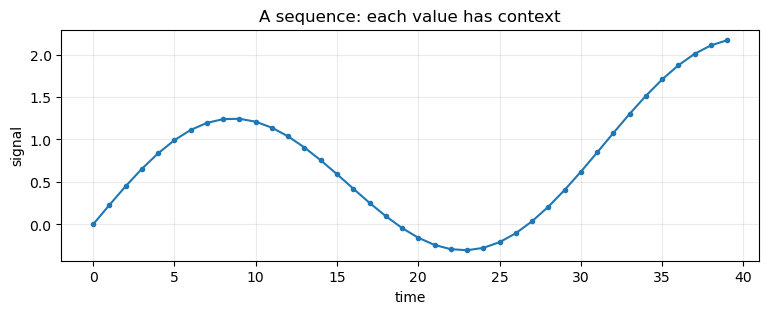

In [3]:
t = np.arange(40)
x = np.sin(t / 5) + 0.03 * t
plt.figure(figsize=(9,3)); plt.plot(t, x, marker="o", ms=3); plt.title("A sequence: each value has context"); plt.xlabel("time"); plt.ylabel("signal"); plt.grid(alpha=.25); plt.show()


## Track contract
        Every later notebook uses `(batch, time, features)` for sequence tensors. The flagship project uses chronological splitting and training-only normalization to prevent leakage.
